In [49]:
import sys
from pathlib import Path

# Add src/utils to sys.path
sys.path.append(str(Path().resolve().parent / "src" / "utils"))

from pathlib import Path

from rich import print
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from nltk.probability import FreqDist
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from wordcloud import WordCloud

# from . import preprocess_text
from text_mining import preprocess_text
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Elements of text preprocessing
* Lower-case all words
* Remove hyperlinks
* Remove punctuation and special characters
* Remove stopwords
* Expand contraction (i.e., you're -> you are, won't -> will not)
* Word stemming (pay, paying, payment -> pay): Removing suffix of words (e.g., change, changing -> chang)
* Word lemmatization (change, changing -> change)
* Remove numbers or convert numbers to words
* Convert emoticons/emojis to text
* Part-of-speech (POS) tag (I like this company, that's why I rate it with 5 stars.)

In [2]:
# Find all CSV files in ../data/processed/
csv_files = list(Path("../data/processed").glob("cleaned_reviews_part_*.csv"))

# Read and concatenate all CSVs into a single DataFrame
df = pd.concat([pd.read_csv(file, index_col='id', low_memory=False) for file in csv_files], axis=0)

In [3]:
df['text'] = df['text'].astype(str)

**Please bear with us that the following exploratory data analysis is conducted on a sampled version of the whole dataset. This is because preprocessing all review texts (more than 2 million) would have the computer running for more than 1 day. We may conduct it later on, but for the moment, we stick to a mere 25,000 sample dataset.**

In [ ]:
n_samples = 25000
clean_text = df['text'].copy().sample(n=n_samples, random_state=42)

In [19]:
clean_text = clean_text.apply(preprocess_text)

In [20]:
clean_text.head()

id
682695d01aadcf94ec3aea94              tariff cancelling soon burn last credit
662a212bddb79d3a3b1ead31    given three waiting make first shout unfortuna...
67facfac6e18b4a46adc5750                                     nice application
5afb76de6d33bc0b083fa127                  easy ordering customer service best
59f20aa0dc938904f8e20519                                                 good
Name: text, dtype: object

In [29]:
df_sampled = df.loc[clean_text.index]
df_sampled['clean_text'] = clean_text

In [ ]:
df_sampled.to_csv('../data/processed/cleaned_reviews_sampled_preprocessed.csv', index=True, index_label='id')

In [34]:
# Tokenize all words in the clean_text column
all_words = word_tokenize(' '.join(df_sampled['clean_text'].to_list()))

# Create frequency distribution
fdist = FreqDist(all_words)

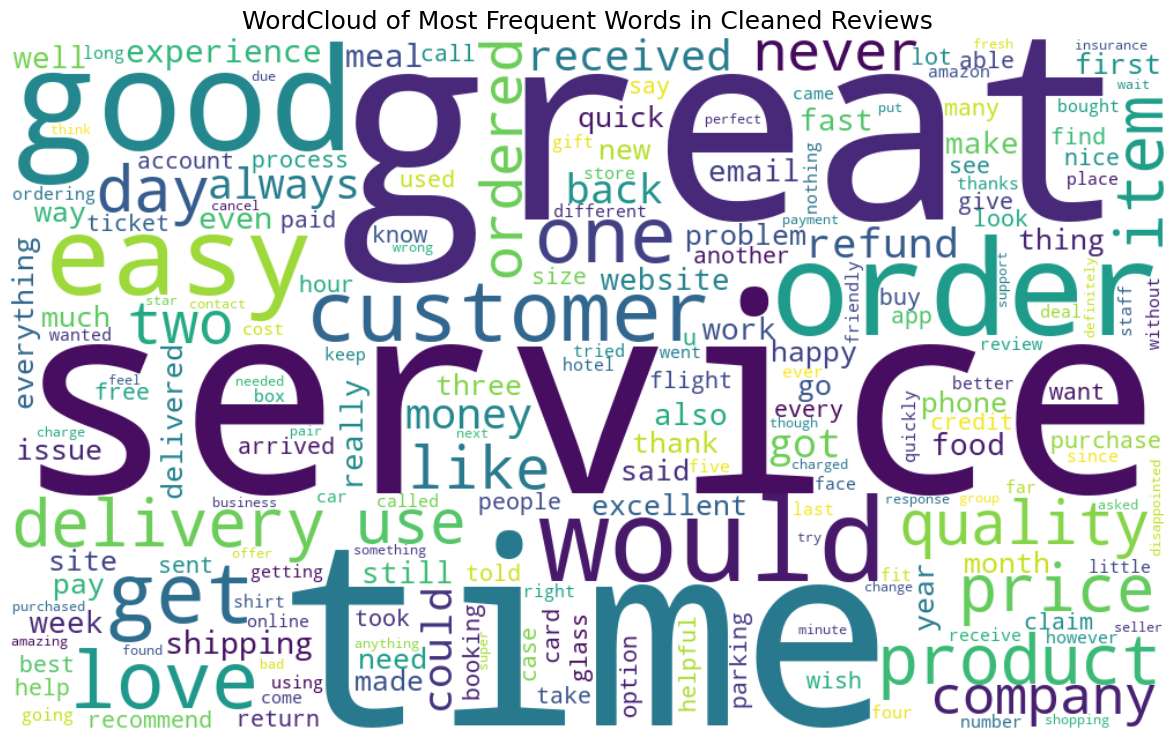

In [ ]:
# Generate wordcloud from frequency distribution
wordcloud = WordCloud(width=1000, height=600, background_color='white').generate_from_frequencies(fdist)

plt.figure(figsize=(16, 9))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Most Frequent Words in Cleaned Reviews', fontsize=18)
plt.show()

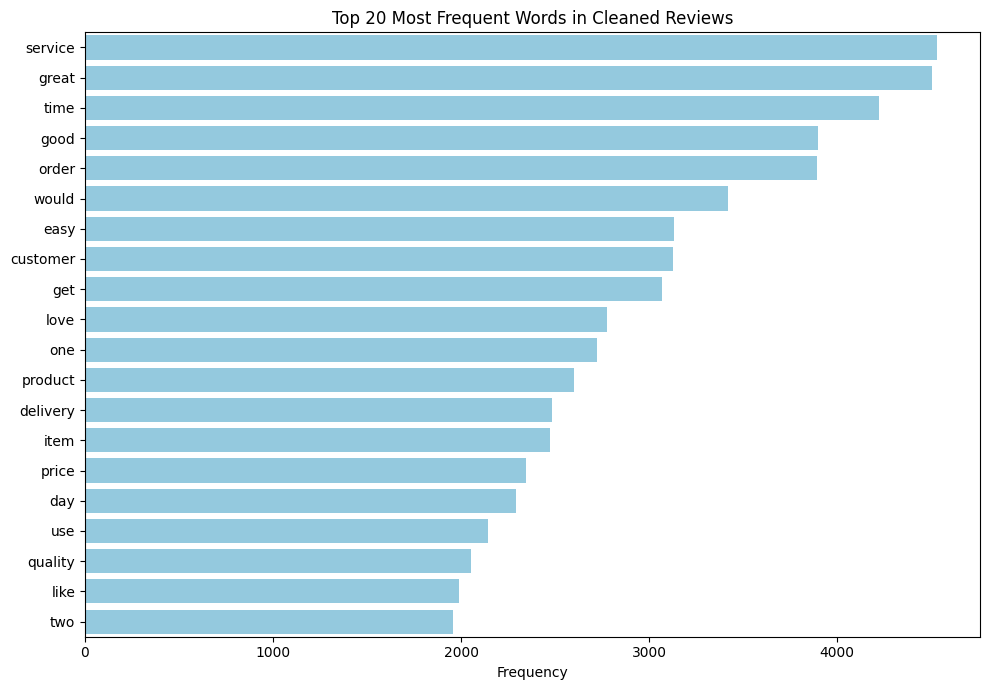

In [40]:
# Show the 20 most common words as a horizontal bar chart using seaborn
top_n = 20
most_common_words = fdist.most_common(top_n)
words, counts = zip(*most_common_words)

plt.figure(figsize=(10, 7))
sns.barplot(x=list(counts), y=list(words), color='skyblue')
plt.xlabel('Frequency')
plt.title(f'Top {top_n} Most Frequent Words in Cleaned Reviews')
plt.tight_layout()
plt.show()

Regardless of the rating, the words "service" and "great" are the most often occurring words in the sampled reviews. The word "service" is expected to be found in positive as well as negative reviews. The word "great" indicates positivity at first glance. But since no negation handling has been performed, this word may be contained in negative reviews in negated form. Using N-Gram analysis should help reveal if this is the case. The bit less often used words "time", "good", and "order" all may indicate something positive as well as something negative. 

More insights should be obtained by studying the word frequency distribution by rating individually.

Most common words in negative reviews:

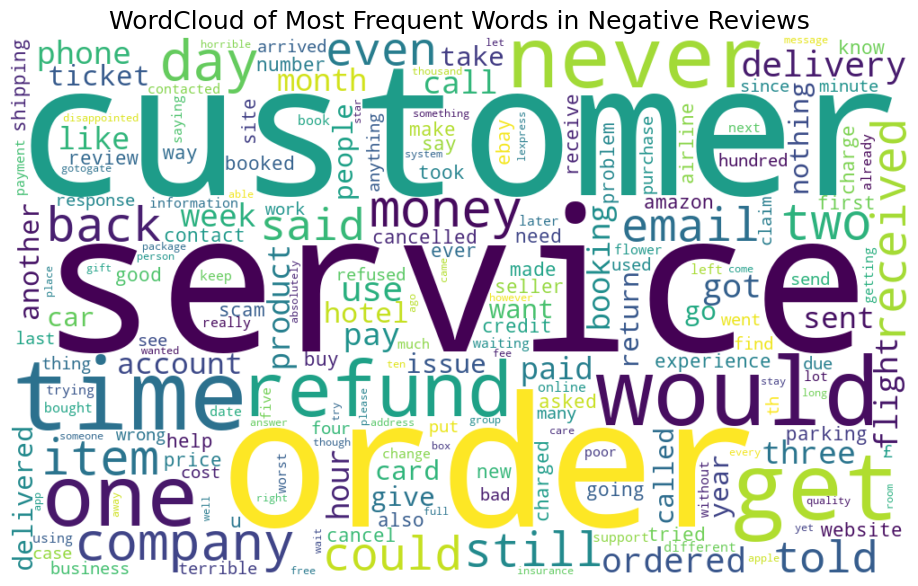

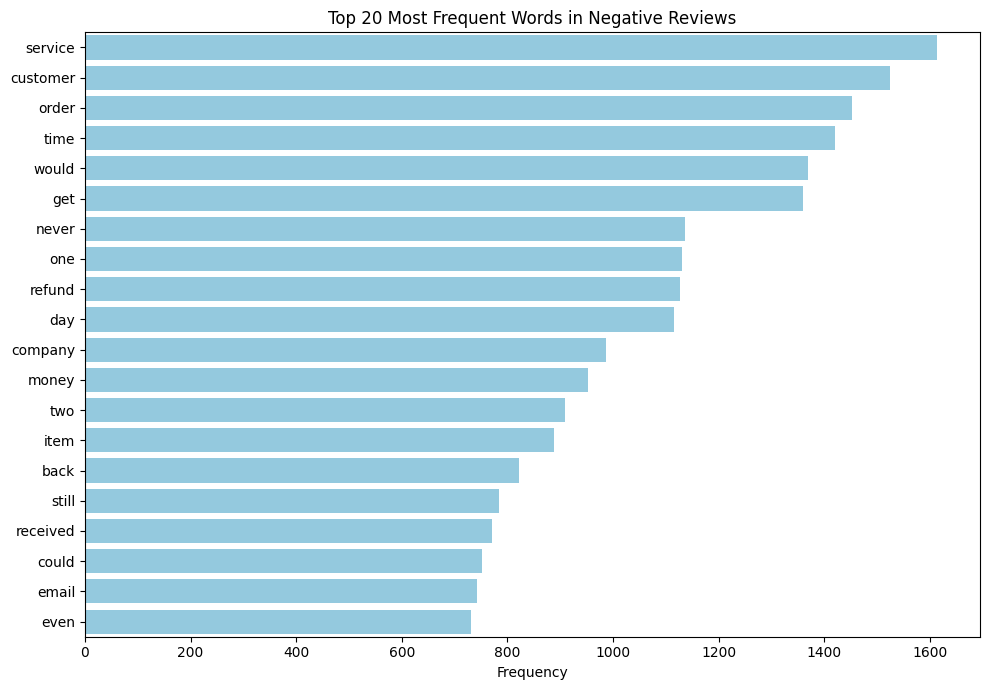

Most common words in neutral reviews:

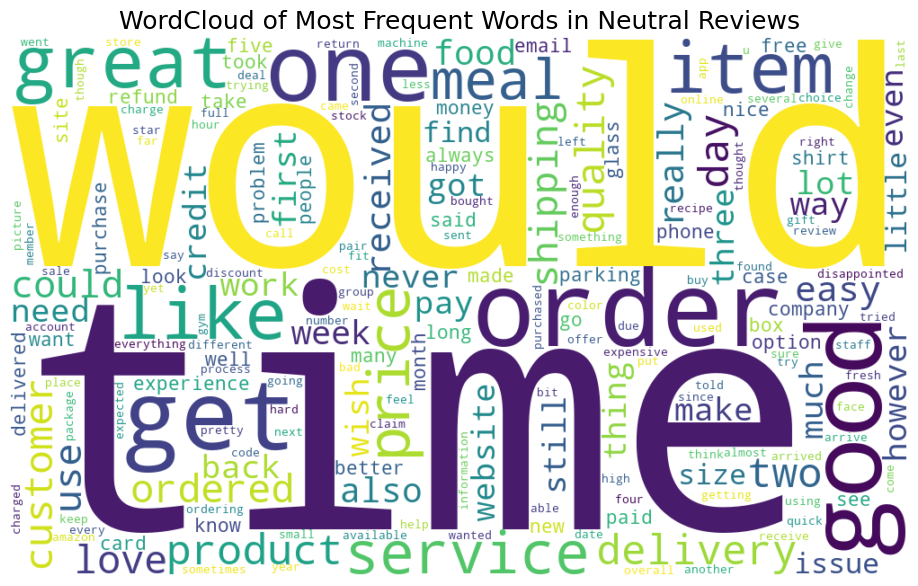

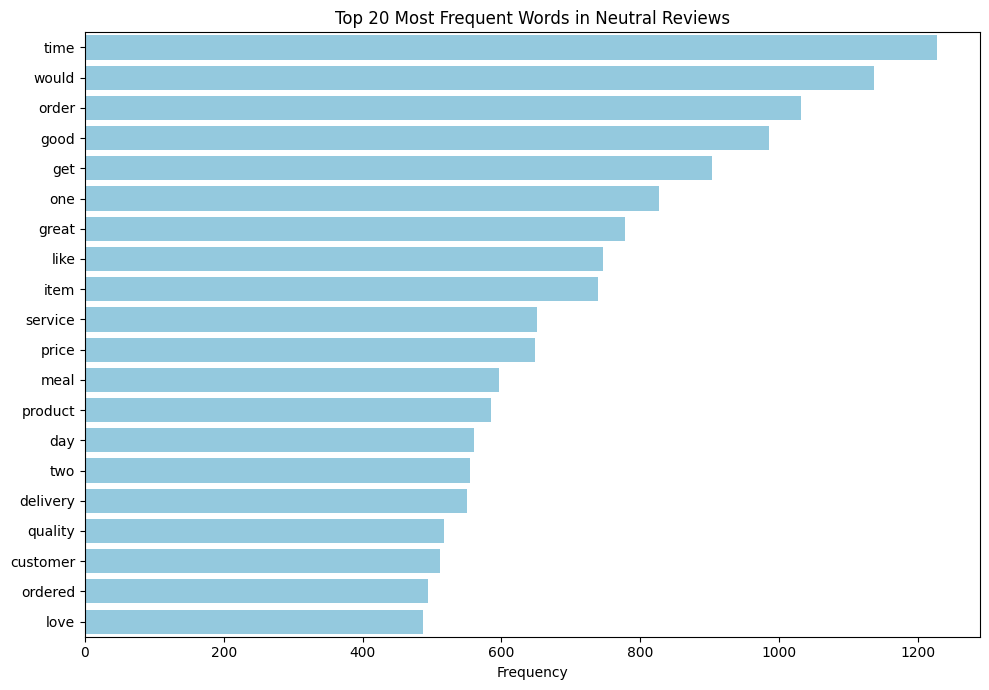

Most common words in positive reviews:

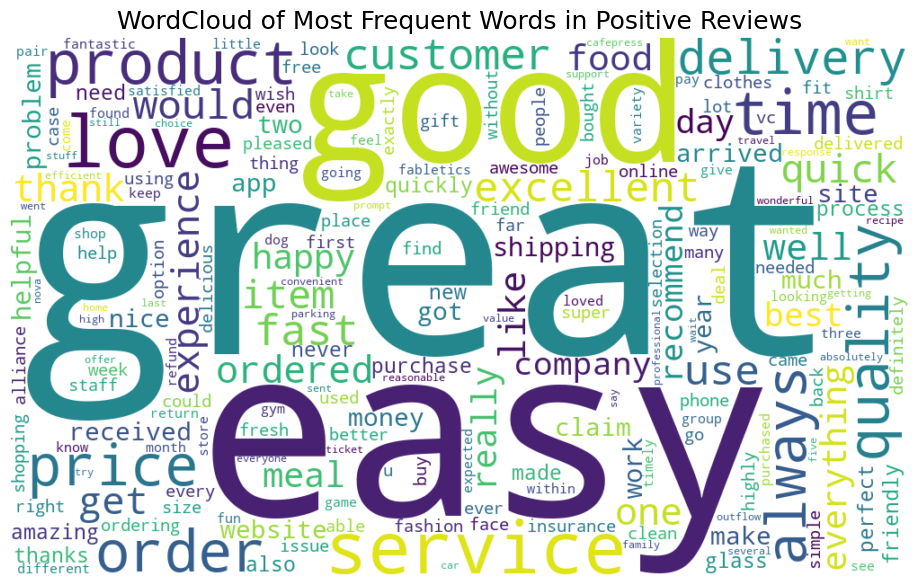

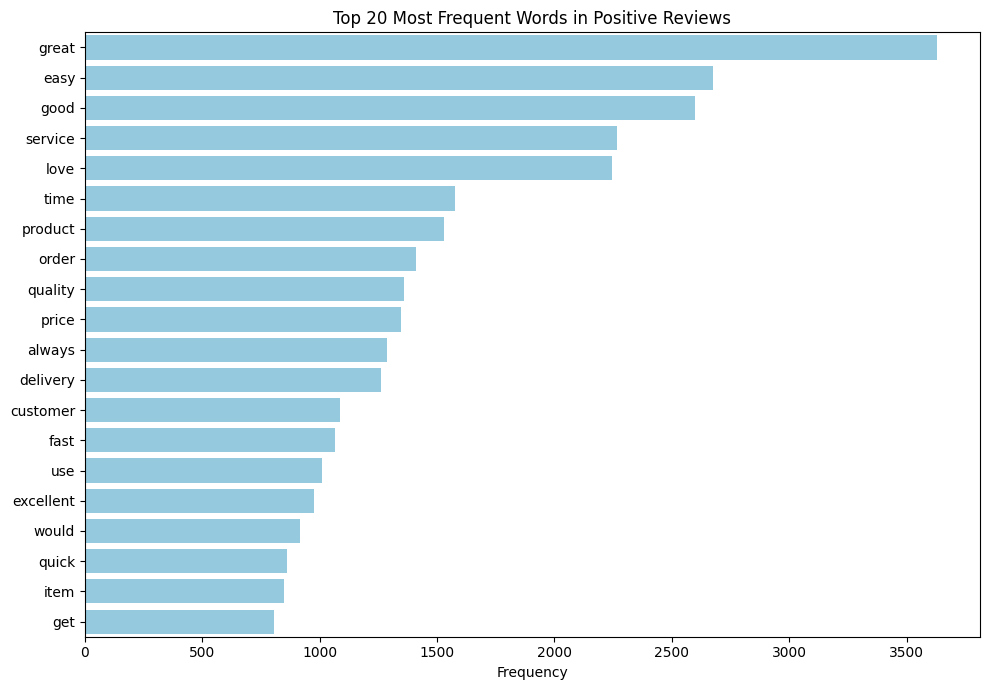

In [42]:
for rating_group in [[1], [2,3,4], [5]]:
    if rating_group == [1]:
        rating = 'negative'
    elif rating_group == [2, 3, 4]:
        rating = 'neutral'
    else:
        rating = 'positive'
        
    print(f"Most common words in {rating} reviews:")
    words = word_tokenize(' '.join(df_sampled.loc[df_sampled['rating'].isin(rating_group), 'clean_text'].to_list()))
    fdist_rating = FreqDist(words)
    
    # Wordcloud
    wordcloud_rating = WordCloud(width=1000, height=600, background_color='white').generate_from_frequencies(fdist_rating)
    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud_rating, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud of Most Frequent Words in {rating.capitalize()} Reviews", fontsize=18)
    plt.show()
    
    top_n = 20
    most_common_words_rating = fdist_rating.most_common(top_n)
    words, counts = zip(*most_common_words_rating)

    plt.figure(figsize=(10, 7))
    sns.barplot(x=list(counts), y=list(words), color='skyblue')
    plt.xlabel('Frequency')
    plt.title(f"Top {top_n} Most Frequent Words in {rating.capitalize()} Reviews")
    plt.tight_layout()
    plt.show()

As can be seen in the 1-star distribution, the most frequent words "service", "customer", "order", "time", "would", "get" contain 4 of the top words from the overall distribution. Hence, many negations are reflected here. The word "customer" is highly visible, most probably due to close relation to customer service (both words are in the top list).

Compared to that, the most often used words for 5-star ratings are "great", "easy", "good", "service", and "love". It is not surprising that most of them are adjectives. The word "service" we already encountered in the overall as well as the 1-star rating word frequency distribution. Hence, we can state that negative reviews are dominated by nouns, while positive reviews are composed of adjectives in high number.

With top words "time", "would", "order", "get", and "good", the intersection with negative reviews is much more present than with the positive ones (sharing "good" only), although 4 star ratings are represented more than the other two. 


Most common 2-grams in 1-star reviews:

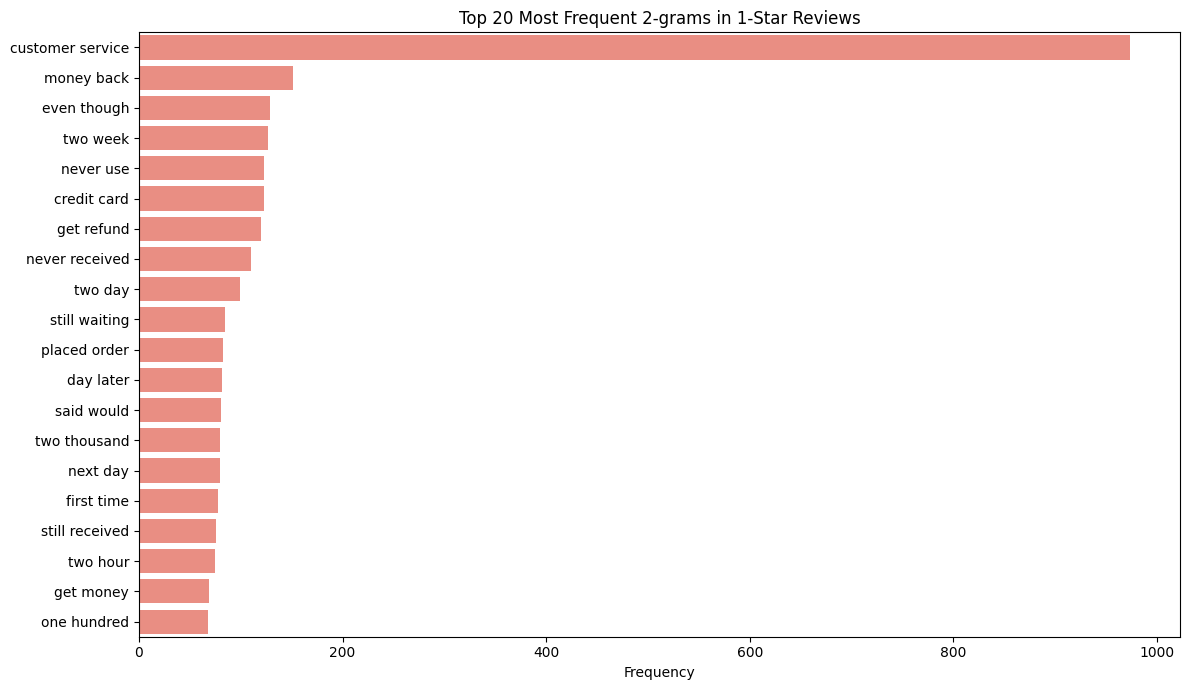

Most common 3-grams in 1-star reviews:

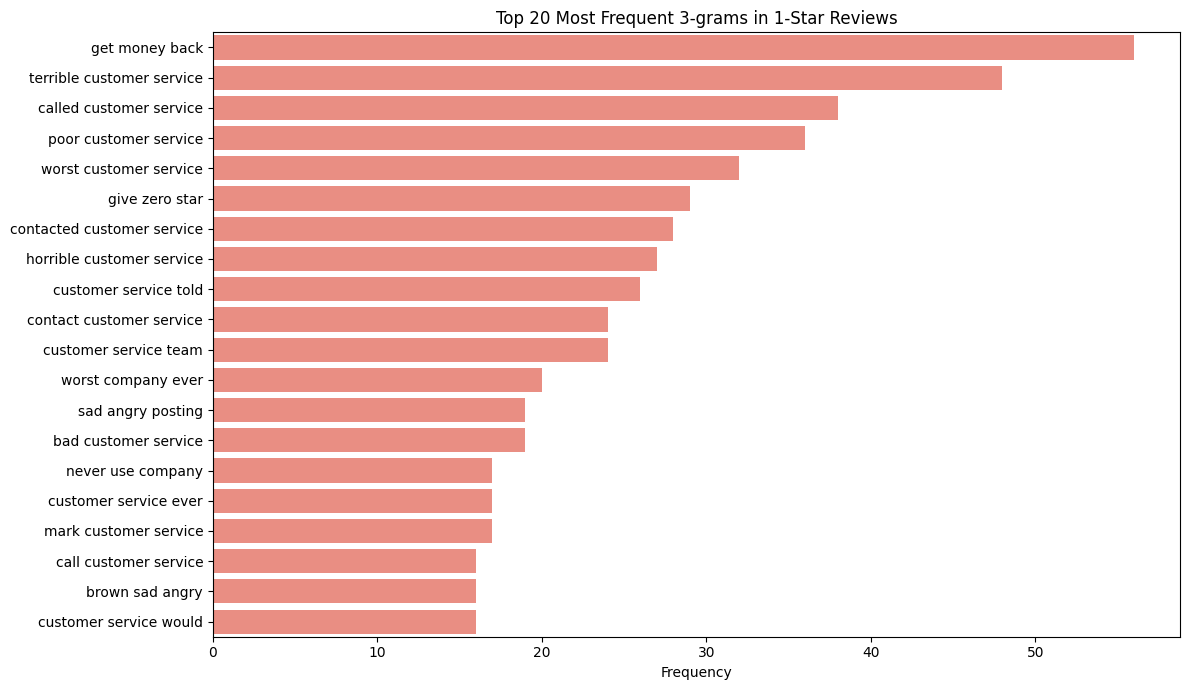

Most common 2-grams in 5-star reviews:

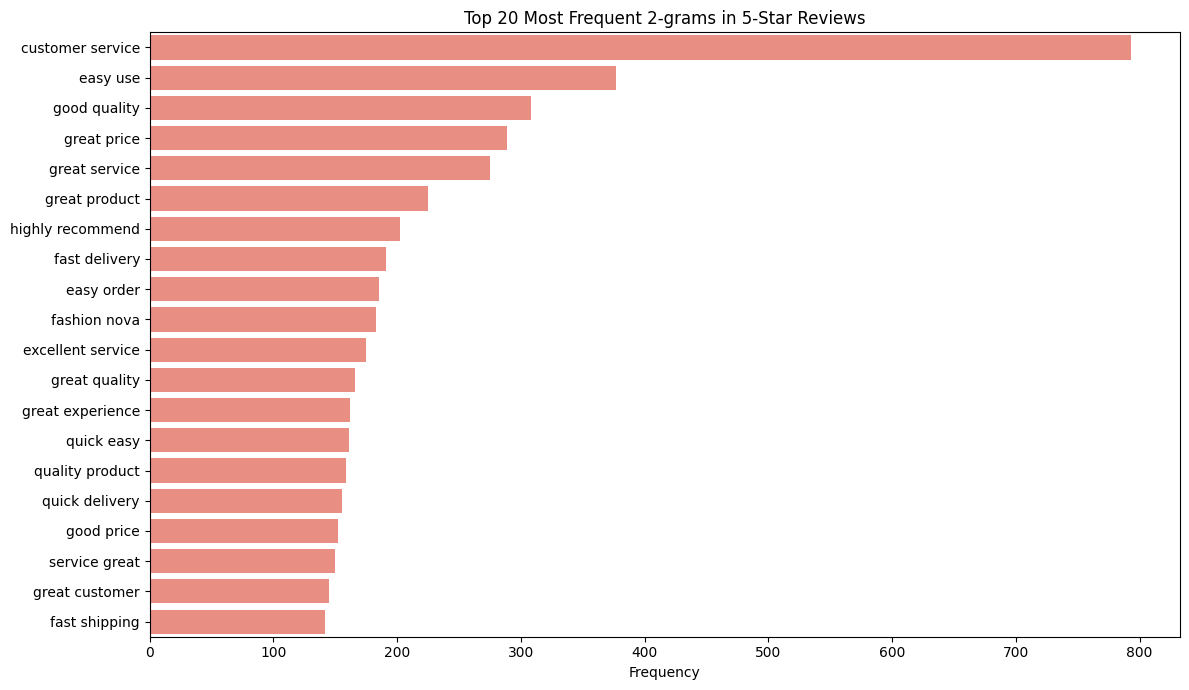

Most common 3-grams in 5-star reviews:

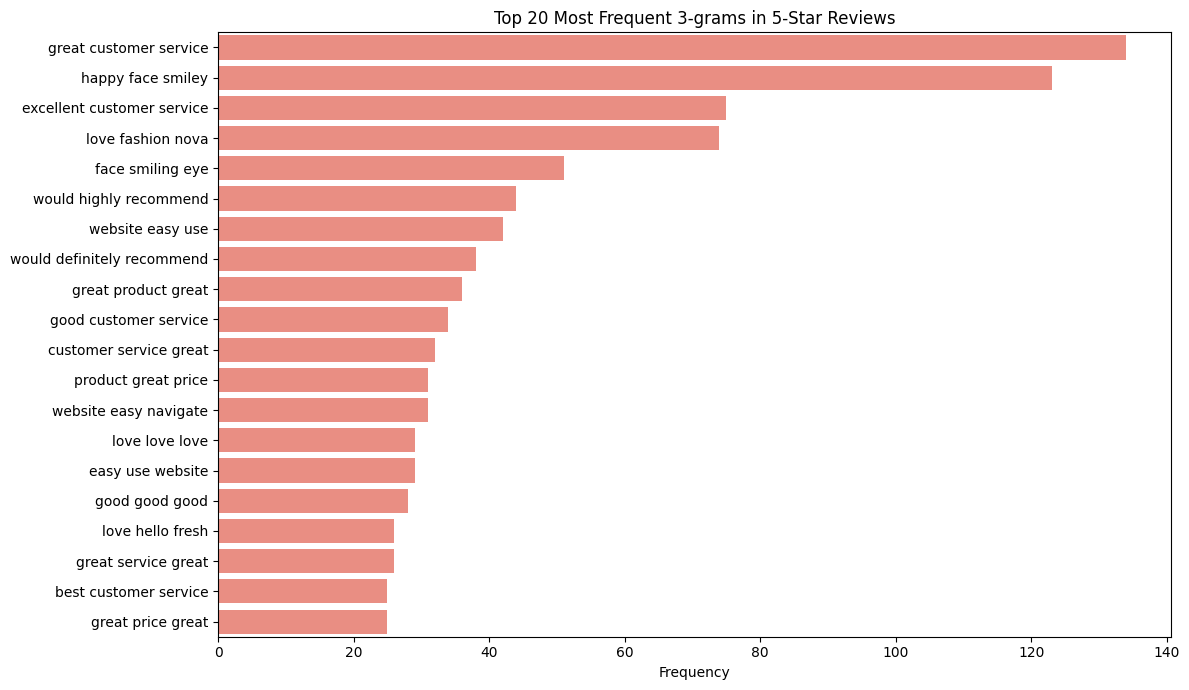

In [51]:
for rating in [1, 5]:
    for n in [2, 3]:
        print(f"Most common {n}-grams in {rating}-star reviews:")
        words = word_tokenize(' '.join(df_sampled.loc[df_sampled['rating'] == rating, 'clean_text'].to_list()))
        n_grams = list(ngrams(words, n))
        fdist_ngrams = FreqDist(n_grams)
        ngram_labels, ngram_counts = zip(*fdist_ngrams.most_common(top_n))
        ngram_labels = [' '.join(b) for b in ngram_labels]
        
        plt.figure(figsize=(12, 7))
        sns.barplot(x=list(ngram_counts), y=ngram_labels, color='salmon')
        plt.xlabel('Frequency')
        plt.title(f'Top {top_n} Most Frequent {n}-grams in {rating}-Star Reviews')
        plt.tight_layout()
        plt.show()

In both, positive as well as negative customer reviews, "customer service" is the distinct leader of 2-grams. This means that the majority of reviews credits customer service for good or bad experience. For negative reviews, this is further supported by the top 3-grams which clearly shows that "customer service" is used in conjunction with a variety of different negative adjectives. For positive reviews, on the other hand, the 3-grams show that "customer service" is less representative. Further, it can be seen that emojis and/or emoticons are used very often to express happiness towards stores. Even a specific store is mentioned often in positive reviews. 

To summarize, "customer service" with additional adjectives is the most promonent topic in negative reviews. "Customer service" is also very relevant in positive reviews, but emojis and emoticons are very present as well.

One could speculate that creating a simple classifier which maps any review text containing "customer" and "service" in conjunction with adjectives describing something negative would not perform that bad. One may consider this simple classifier as baseline model.

## TODO
* Polarity
* Topic modelling
* Named entity recognition
* POS tagging
* Text complexity (how readable/difficult to read)
* Sentence length analysis
